# Radiosonde Data Analysis with PyRadtran

This notebook demonstrates how to use PyRadtran with real atmospheric measurement data from the HALO-AC3 Arctic campaign. The HALO-AC3 (HALO - (AC)³) mission studied Arctic amplification and its connection to mid-latitude weather patterns.

## Objectives

In this notebook, we will:

1. **Load real aircraft measurement data** from the HALO-AC3 campaign
2. **Run radiative transfer simulations** using PyRadtran with the measurement data as input
3. **Compare simulated and measured albedo** values at different altitudes
4. **Visualize the results** with time series and scatter plots to assess model performance

## Dataset

The dataset contains broadband radiation measurements from the HALO research aircraft, including:
- Measured albedo values over Arctic sea ice and leads
- Aircraft position data (latitude, longitude, altitude)
- Atmospheric conditions during the flight

## Key Features Demonstrated

- **Real data integration**: Using actual atmospheric measurement data
- **Multi-altitude analysis**: Comparing simulations at different output altitudes
- **Validation techniques**: Statistical comparison between measurements and simulations
- **Visualization**: Creating publication-quality plots for scientific analysis

In [1]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/HALO-AC3_HALO_solar_disort.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

In [2]:
ds = xr.open_dataset('data/HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc').interpolate_na('time')

# the albedo has over 30% missing values, so we interpolate it for now


/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [3]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    output_path='data/Simulated_HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc',
    albedo_var='albedo',
)

print("\nSimulation complete!")
ds_sim

2025-07-22 00:56:56,861 - pyradtran.interface - INFO - Altitude found as coordinate - using 15 levels for zout: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
2025-07-22 00:56:56,862 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-07-22 00:56:56,873 - pyradtran.utils - INFO - Found and parsed 323 radiosonde files.
2025-07-22 00:56:56,936 - pyradtran.interface - INFO - Running 149 simulations across time/location points...


Running batch spectral simulation...


2025-07-22 00:56:57,124 - pyradtran.core - DEBUG - Time 2022-03-14 13:50:00 -> Closest Sonde: 20220314_51225SOD.dat
2025-07-22 00:56:57,124 - pyradtran.core - DEBUG - Time 2022-03-14 10:30:00 -> Closest Sonde: 20220314_37586SOD.dat
2025-07-22 00:56:57,127 - pyradtran.core - DEBUG - Time 2022-03-14 15:20:00 -> Closest Sonde: 20220314_55054SOD.dat
2025-07-22 00:56:57,128 - pyradtran.core - DEBUG - Time 2022-03-14 14:00:00 -> Closest Sonde: 20220314_51225SOD.dat
2025-07-22 00:56:57,130 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220314_135000_clobc0av.inp
2025-07-22 00:56:57,131 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220314_103000_2hzgu1xp.inp
2025-07-22 00:56:57,131 - pyradtran.core - DEBUG - Running uvspec: /opt/libradtran/2.0.4/bin/uvspec < uvspec_20220314_135000_clobc0av.inp > uvspec_202


Simulation complete!


<xarray.Dataset> Size: 129kB
Dimensions:    (time: 149, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2022-03-14T10:30:00 ... 2022-04-11T1...
    latitude   (time) float64 1kB 79.38 82.61 81.79 80.14 ... 84.94 85.93 85.46
    longitude  (time) float64 1kB 27.16 3.475 1.575 4.314 ... 9.461 16.73 12.38
  * altitude   (altitude) float64 120B 0.0 1.0 2.0 3.0 ... 11.0 12.0 13.0 14.0
Data variables:
    sza        (time, altitude) float64 18kB 180.0 180.0 180.0 ... nan nan nan
    edir       (time, altitude) float64 18kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    eglo       (time, altitude) float64 18kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    edn        (time, altitude) float64 18kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    eup        (time, altitude) float64 18kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    enet       (time, altitude) float64 18kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    albedo     (time, altitude) float64 18kB nan nan nan nan ... nan nan nan nan
Attributes:
    created:            2025-07-22T00:59:29.632159
    source:             PyRadtran
    output_type:        integrated_multi_altitude
    num_simulations:    142
    generated_by:       pyradtran
    pyradtran_version:  new_io_system

## Simulation Results

The simulation has completed successfully! Let's examine what was computed:

- **Input data**: Real atmospheric measurements from HALO-AC3 campaign
- **Simulation type**: Spectral radiative transfer using DISORT solver
- **Output altitudes**: Multiple levels from surface to aircraft altitude
- **Variables computed**: Albedo, upward/downward radiation fluxes

The simulation results are stored in an xarray Dataset with the same time coordinates as the input data, but with an additional altitude dimension representing different output levels.

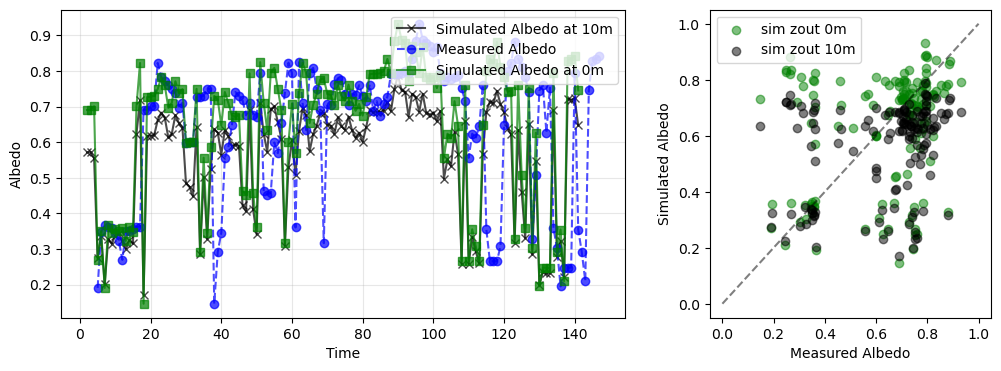

In [4]:
albedo_sim_z0 = ds_sim.albedo.isel(altitude=0)
albedo_sim_z10 = ds_sim.albedo.isel(altitude=10)
albedo_meas = ds.albedo

fig, (ax, ax_scatter) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]}, figsize=(12, 4))
ax.plot(albedo_sim_z10, label='Simulated Albedo at 10m', linestyle='-', marker='x', color='black', alpha=0.7)
ax.plot(albedo_meas, label='Measured Albedo', linestyle='--', marker='o', color='blue', alpha=0.7)
ax.plot(albedo_sim_z0, label='Simulated Albedo at 0m', linestyle='-', marker='s', color='green', alpha=0.7  )
ax.grid(alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Albedo')
ax.legend(loc='upper right')

ax_scatter.scatter(albedo_meas, albedo_sim_z0, label='sim zout 0m', color='green', alpha=0.5)
ax_scatter.scatter(albedo_meas, albedo_sim_z10, label='sim zout 10m', color='black', alpha=0.5)
ax_scatter.plot([0, 1], [0, 1], linestyle='--', color='k', alpha=0.5)
ax_scatter.set_xlabel('Measured Albedo')
ax_scatter.set_ylabel('Simulated Albedo')
ax_scatter.legend(loc='upper left')
